# Exp0.2 — Shift-resolved final-hidden firing-rate analysis

Checkpoint-only analysis. This notebook never trains or evaluates models; it reads finalized CSV artifacts produced by the Slurm post-evaluation pipeline. The primary question is whether regularization preferentially suppresses long-τ neurons, especially after the endpoint, or merely reduces firing globally.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_0_2_endpoint_tail_regularization' / 'endpoint_tail_regularization_v1' / 'experiment_0_2_shift_resolved_fire_rate' / 'shift_fire_rate_v1'
summary = pd.read_csv(ROOT / 'shift_fire_rate_summary.csv')
comparison = pd.read_csv(ROOT / 'shift_fire_rate_comparison.csv')
paired = pd.read_csv(ROOT / 'shift_fire_rate_vs_none.csv')
long_tau = pd.read_csv(ROOT / 'shift_fire_rate_long_tau_summary.csv')
long_tau_comparison = pd.read_csv(ROOT / 'shift_fire_rate_long_tau_comparison.csv')
long_tau_paired = pd.read_csv(ROOT / 'shift_fire_rate_long_tau_vs_none.csv')
print('per-shift rows:', len(summary))
display(summary.head())

per-shift rows: 480


,architecture,objective,profile,seed,shift,alpha,tau_syn_ms,tau_group,neuron_start,neuron_stop,...,tail_stage1_firing_rate_hz,tail_stage2_firing_rate_hz,tail_stage3_firing_rate_hz,tail_firing_rate_hz,valid_spikes_per_neuron_sample,tail_stage1_spikes_per_neuron_sample,tail_stage2_spikes_per_neuron_sample,tail_stage3_spikes_per_neuron_sample,tail_spikes_per_neuron_sample,tail_to_valid_rate_ratio
0,short_mid_long,whole_count_ce,none,11,2,0.750000,54.313430,short_mid,0,22,...,2.860044,1.571032,0.815276,1.773350,2.943337,0.580946,0.319116,0.152864,1.052927,0.778396
1,short_mid_long,whole_count_ce,none,11,3,0.875000,117.013683,short_mid,22,44,...,4.392758,2.758885,1.997509,3.077407,4.976339,0.892279,0.560399,0.374533,1.827210,0.798953
2,short_mid_long,whole_count_ce,none,11,4,0.937500,242.103471,short_mid,44,65,...,5.626374,4.211752,2.972820,4.304460,6.071102,1.142857,0.855512,0.557404,2.555773,0.916004
3,short_mid_long,whole_count_ce,none,11,5,0.968750,492.146161,short_mid,65,86,...,13.964775,12.379949,10.517069,12.333848,11.003914,2.836595,2.514677,1.971950,7.323222,1.448098
4,short_mid_long,whole_count_ce,none,11,6,0.984375,992.166994,long,86,107,...,13.587435,12.856842,12.013046,12.840320,9.613503,2.759948,2.611546,2.252446,7.623940,1.725602


## 1. Mean firing rate by synaptic shift
This is the direct per-shift measurement. Compare `none` with each regularized profile for valid-region FR and full-tail FR.

In [2]:
cols = [
    'architecture', 'objective', 'profile', 'shift',
    'valid_firing_rate_hz_mean', 'tail_firing_rate_hz_mean',
    'tail_stage1_firing_rate_hz_mean', 'tail_stage2_firing_rate_hz_mean',
    'tail_stage3_firing_rate_hz_mean',
]
display(comparison[cols].sort_values(['architecture', 'objective', 'shift', 'profile']))

,architecture,objective,profile,shift,valid_firing_rate_hz_mean,tail_firing_rate_hz_mean,tail_stage1_firing_rate_hz_mean,tail_stage2_firing_rate_hz_mean,tail_stage3_firing_rate_hz_mean
0,mid_long,timestep_ce,a1,2,0.199691,0.057853,0.155826,0.013284,0.000000
6,mid_long,timestep_ce,a1_p2,2,0.321786,0.074283,0.201807,0.015327,0.000000
12,mid_long,timestep_ce,a1_tail,2,0.687913,0.169365,0.455727,0.039340,0.000000
18,mid_long,timestep_ce,none,2,3.638131,1.319438,3.240157,0.592649,0.026014
24,mid_long,timestep_ce,tail,2,1.835291,0.417907,1.117859,0.103714,0.000000
...,...,...,...,...,...,...,...,...,...
135,short_mid_long,whole_count_ce,a1,7,1.162969,2.789622,2.888119,2.797665,2.674205
141,short_mid_long,whole_count_ce,a1_p2,7,1.270514,3.014111,3.090973,3.037985,2.904979
147,short_mid_long,whole_count_ce,a1_tail,7,1.424090,3.074536,3.165906,3.073845,2.976299
153,short_mid_long,whole_count_ce,none,7,6.338603,11.417585,11.742486,11.427769,11.054577


## 2. Paired percentage change versus frozen Exp0.1 none
Negative percentage changes mean lower firing after regularization. `tail_specific_suppression_pp > 0` means the tail FR was reduced more strongly than the valid-region FR for the same architecture/objective/seed/shift.

In [3]:
view = paired[paired['profile'] != 'none'].copy()
show = [
    'architecture', 'objective', 'profile', 'seed', 'shift', 'tau_syn_ms',
    'pct_change_valid_firing_rate_hz_vs_none',
    'pct_change_tail_firing_rate_hz_vs_none',
    'tail_specific_suppression_pp',
    'tail_stage1_specific_suppression_pp',
    'tail_stage2_specific_suppression_pp',
    'tail_stage3_specific_suppression_pp',
]
display(view[show].sort_values(['architecture', 'objective', 'profile', 'seed', 'shift']))

,architecture,objective,profile,seed,shift,tau_syn_ms,pct_change_valid_firing_rate_hz_vs_none,pct_change_tail_firing_rate_hz_vs_none,tail_specific_suppression_pp,tail_stage1_specific_suppression_pp,tail_stage2_specific_suppression_pp,tail_stage3_specific_suppression_pp
408,mid_long,timestep_ce,a1,11,2,54.313430,-98.252625,-99.914676,1.662051,1.647525,1.747375,1.747375
409,mid_long,timestep_ce,a1,11,3,117.013683,-97.295715,-97.098446,-0.197269,-0.821534,1.506129,2.704285
410,mid_long,timestep_ce,a1,11,4,242.103471,-91.571309,-90.683430,-0.887879,-4.318369,1.095986,6.755240
411,mid_long,timestep_ce,a1,11,5,492.146161,-92.755796,-92.613119,-0.142676,-2.050332,0.009554,2.581825
412,mid_long,timestep_ce,a1,11,6,992.166994,-89.042164,-87.923407,-1.118756,-2.243930,-1.122186,0.312970
...,...,...,...,...,...,...,...,...,...,...,...,...
67,short_mid_long,whole_count_ce,tail,37,3,117.013683,-65.502533,-72.104629,6.602096,-3.242836,10.606115,27.683648
68,short_mid_long,whole_count_ce,tail,37,4,242.103471,-75.630208,-75.713565,0.083357,-4.554661,0.877912,7.733182
69,short_mid_long,whole_count_ce,tail,37,5,492.146161,-64.942549,-59.705341,-5.237208,-6.473203,-6.170619,-2.346690
70,short_mid_long,whole_count_ce,tail,37,6,992.166994,-59.186033,-56.329821,-2.856213,-3.846753,-2.884818,-1.625138


## 3. Tail firing-rate curves across shifts
Use the same axes to see whether suppression grows with τ.

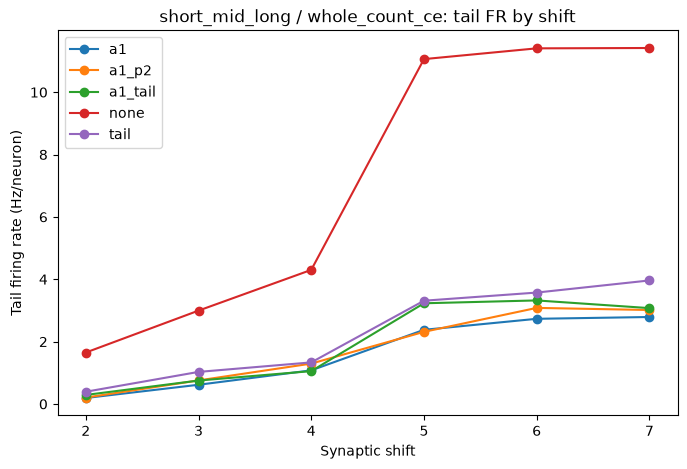

In [4]:
ARCHITECTURE = 'short_mid_long'
OBJECTIVE = 'whole_count_ce'
plot_df = comparison[(comparison['architecture'] == ARCHITECTURE) & (comparison['objective'] == OBJECTIVE)].copy()
fig, ax = plt.subplots(figsize=(8, 5))
for profile, frame in plot_df.groupby('profile'):
    frame = frame.sort_values('shift')
    ax.plot(frame['shift'], frame['tail_firing_rate_hz_mean'], marker='o', label=profile)
ax.set_xlabel('Synaptic shift')
ax.set_ylabel('Tail firing rate (Hz/neuron)')
ax.set_title(f'{ARCHITECTURE} / {OBJECTIVE}: tail FR by shift')
ax.legend()
plt.show()

## 4. Endpoint selectivity across shifts
Positive values are the desired behavior: tail firing falls more than valid firing. Values near zero indicate mostly global suppression.

,architecture,objective,profile,shift,tail_specific_suppression_pp
0,mid_long,timestep_ce,a1,2,0.695701
1,mid_long,timestep_ce,a1,3,0.623751
2,mid_long,timestep_ce,a1,4,1.297888
3,mid_long,timestep_ce,a1,5,0.710809
4,mid_long,timestep_ce,a1,6,-1.558879
...,...,...,...,...,...
123,short_mid_long,whole_count_ce,tail,3,5.534201
124,short_mid_long,whole_count_ce,tail,4,0.271614
125,short_mid_long,whole_count_ce,tail,5,0.710547
126,short_mid_long,whole_count_ce,tail,6,-1.036818


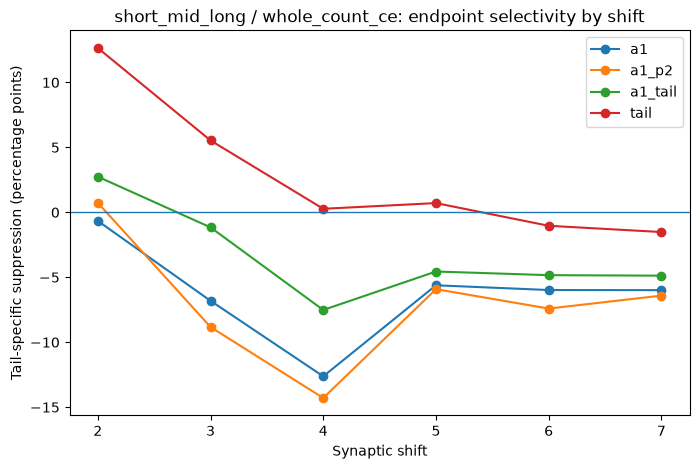

In [5]:
selectivity = (
    view.groupby(['architecture', 'objective', 'profile', 'shift'], as_index=False)['tail_specific_suppression_pp']
        .mean()
)
display(selectivity.sort_values(['architecture', 'objective', 'profile', 'shift']))

plot_sel = selectivity[(selectivity['architecture'] == ARCHITECTURE) & (selectivity['objective'] == OBJECTIVE)]
fig, ax = plt.subplots(figsize=(8, 5))
for profile, frame in plot_sel.groupby('profile'):
    frame = frame.sort_values('shift')
    ax.plot(frame['shift'], frame['tail_specific_suppression_pp'], marker='o', label=profile)
ax.axhline(0, linewidth=1)
ax.set_xlabel('Synaptic shift')
ax.set_ylabel('Tail-specific suppression (percentage points)')
ax.set_title(f'{ARCHITECTURE} / {OBJECTIVE}: endpoint selectivity by shift')
ax.legend()
plt.show()

## 5. Pooled long-τ view
The pooled long group uses configured final-hidden s6/s7 neurons (shift ≥6, about 1–2 s at 64 Hz). `short_mid` therefore has no pooled long-τ row; its s2-s5 results remain in the per-shift tables.

In [6]:
display(long_tau_comparison.sort_values(['architecture', 'objective', 'profile']))
display(
    long_tau_paired[long_tau_paired['profile'] != 'none'][[
        'architecture', 'objective', 'profile', 'seed', 'long_shifts',
        'pct_change_valid_firing_rate_hz_vs_none',
        'pct_change_tail_firing_rate_hz_vs_none',
        'tail_specific_suppression_pp',
    ]].sort_values(['architecture', 'objective', 'profile', 'seed'])
)

,architecture,objective,profile,valid_firing_rate_hz_mean,valid_firing_rate_hz_std,tail_stage1_firing_rate_hz_mean,tail_stage1_firing_rate_hz_std,tail_stage2_firing_rate_hz_mean,tail_stage2_firing_rate_hz_std,tail_stage3_firing_rate_hz_mean,tail_stage3_firing_rate_hz_std,tail_firing_rate_hz_mean,tail_firing_rate_hz_std,tail_to_valid_rate_ratio_mean,tail_to_valid_rate_ratio_std
0,mid_long,timestep_ce,a1,2.171185,2.527996,4.236372,4.753481,3.929148,4.473206,3.544249,4.137395,3.912704,4.462820,1.551828,0.637264
1,mid_long,timestep_ce,a1_p2,2.238968,2.687684,4.453677,5.162651,4.140833,4.938060,3.724868,4.606913,4.116501,4.910159,1.699858,0.409162
2,mid_long,timestep_ce,a1_tail,2.714128,2.399020,4.402027,4.092379,4.061886,3.962435,3.670943,3.796379,4.054795,3.954171,1.386364,0.225529
3,mid_long,timestep_ce,none,12.138934,1.193425,21.866961,1.264405,21.349390,1.183951,20.370805,1.104516,21.217427,1.159141,1.749302,0.163627
4,mid_long,timestep_ce,tail,3.902595,3.443364,5.868834,5.598328,5.399970,5.388195,4.934986,5.252534,5.413534,5.416752,1.292063,0.168984
5,mid_long,whole_count_ce,a1,11.312527,1.490024,21.175439,0.651854,20.763310,0.349749,19.855331,0.537593,20.617571,0.455477,1.844251,0.224796
6,mid_long,whole_count_ce,a1_p2,11.359357,1.670080,21.663572,1.683773,21.293726,1.558122,20.356889,1.497488,21.124409,1.579754,1.891543,0.264436
7,mid_long,whole_count_ce,a1_tail,11.269820,1.442131,20.153144,1.041696,19.630488,0.915019,18.744365,1.006521,19.529463,0.979811,1.744161,0.140380
8,mid_long,whole_count_ce,none,14.605573,1.611613,24.874973,1.231495,24.605215,1.397268,23.793868,1.430528,24.441286,1.343149,1.687394,0.143572
9,mid_long,whole_count_ce,tail,11.473340,1.520554,19.175540,1.194997,18.649138,1.018962,17.836051,0.964899,18.572459,1.059249,1.634080,0.183606


,architecture,objective,profile,seed,long_shifts,pct_change_valid_firing_rate_hz_vs_none,pct_change_tail_firing_rate_hz_vs_none,tail_specific_suppression_pp
48,mid_long,timestep_ce,a1,11,"6,7",-89.240044,-87.800509,-1.439535
49,mid_long,timestep_ce,a1,23,"6,7",-62.185186,-57.343510,-4.841676
50,mid_long,timestep_ce,a1,37,"6,7",-98.360352,-99.281797,0.921445
51,mid_long,timestep_ce,a1_p2,11,"6,7",-91.332572,-90.059584,-1.272988
52,mid_long,timestep_ce,a1_p2,23,"6,7",-59.928423,-53.260985,-6.667438
53,mid_long,timestep_ce,a1_p2,37,"6,7",-96.883045,-97.935672,1.052627
57,mid_long,timestep_ce,a1_tail,11,"6,7",-84.379083,-87.742022,3.362939
58,mid_long,timestep_ce,a1_tail,23,"6,7",-59.203137,-59.025017,-0.178120
59,mid_long,timestep_ce,a1_tail,37,"6,7",-92.509103,-95.545255,3.036152
54,mid_long,timestep_ce,tail,11,"6,7",-81.654887,-88.274501,6.619614
